In [ ]:
"""
schema_crush tutorial - visual walkthrough for builders
========================================================
prereqs: pip install schema_crush matplotlib seaborn umap-learn
"""

# schema_crush: ai-powered biomedical schema mapping

visual walkthrough of the full pipeline.

In [1]:
import warnings
warnings.filterwarnings("ignore")

---
## part 1: architecture overview
---

In [2]:
print("""
SCHEMA_CRUSH PIPELINE
=====================

Source Schema (GDC/HTAN/custom)
        |
        v
+-------------------+
|  FlatMappingDB    |  <- expert knowledge (entity/field/content tiers)
+-------------------+
        |
   +----+----+----+
   |    |    |    |
   v    v    v    v
 Rule BioBERT Magneto VectorStore  <- matchers + semantic search
   |    |    |    |
   +----+----+----+
        |
        v
+-------------------+
|   Calibrators     |  <- tier-aware confidence (isotonic regression)
+-------------------+
        |
        v
+-------------------+
|  KnowledgeBase    |  <- unified access (db + calibrators + vectors)
+-------------------+
        |
        +---> fast path (exact match) ---> FHIR Output
        |
        v
+-------------------+
|  Claude Agent     |  <- @tool calling + multi-turn reasoning
+-------------------+
        |
        v
   FHIR Mapping Output
""")


SCHEMA_CRUSH PIPELINE

Source Schema (GDC/HTAN/custom)
        |
        v
+-------------------+
|  FlatMappingDB    |  <- expert knowledge (entity/field/content tiers)
+-------------------+
        |
   +----+----+----+
   |    |    |    |
   v    v    v    v
 Rule BioBERT Magneto VectorStore  <- matchers + semantic search
   |    |    |    |
   +----+----+----+
        |
        v
+-------------------+
|   Calibrators     |  <- tier-aware confidence (isotonic regression)
+-------------------+
        |
        v
+-------------------+
|  KnowledgeBase    |  <- unified access (db + calibrators + vectors)
+-------------------+
        |
        +---> fast path (exact match) ---> FHIR Output
        |
        v
+-------------------+
|  Claude Agent     |  <- @tool calling + multi-turn reasoning
+-------------------+
        |
        v
   FHIR Mapping Output



---
## part 2: setup - api keys
---

create `.env` in project root with your anthropic key.

In [4]:
print("""
.env file:
----------
ANTHROPIC_API_KEY=sk-ant-api03-xxxxx

get key from: https://console.anthropic.com/settings/keys
""")

import os
key = os.getenv("ANTHROPIC_API_KEY")
print(f"api key loaded: {'yes' if key else 'NO - set ANTHROPIC_API_KEY env var'}")


.env file:
----------
ANTHROPIC_API_KEY=sk-ant-api03-xxxxx

get key from: https://console.anthropic.com/settings/keys

api key loaded: yes


---
## part 3: flat mapping database
---

o(1) lookup normalized tables. source -> destination with tiers.

In [5]:
import pandas as pd
from schema_crush.mappings import load_flat_mappings

db = load_flat_mappings()
print(f"sources: {len(db.sources)}, destinations: {len(db.destinations)}")
print(f"content values: {len(db.content_values)}, content targets: {len(db.content_fhir_targets)}")

sources: 1627, destinations: 1654
content values: 1125, content targets: 1125


### 3a. sources table

each source has id, name, context (parent entity), and tier.

In [6]:
sources_df = pd.DataFrame([
    {"id": s.id, "source": s.source, "context": s.source_context, "tier": s.tier.value}
    for s in list(db.sources.values())[:10]
])
print("sources (head 10):")
print(sources_df.to_string(index=False))

sources (head 10):
                            id                source context   tier
                      gdc:case                  case         entity
          gdc:case.aliquot_ids           aliquot_ids    case  field
          gdc:case.analyte_ids           analyte_ids    case  field
              gdc:case.case_id               case_id    case  field
     gdc:case.created_datetime      created_datetime    case  field
          gdc:case.portion_ids           portion_ids    case  field
           gdc:case.sample_ids            sample_ids    case  field
            gdc:case.slide_ids             slide_ids    case  field
                gdc:case.state                 state    case  field
gdc:case.submitter_aliquot_ids submitter_aliquot_ids    case  field


### 3b. destinations table

each destination links to a source_id and has fhir path.

In [7]:
dests_df = pd.DataFrame([
    {"source_id": d.source_id, "destination": d.destination, "dest_system": d.dest_system or "-", "dest_code": d.dest_code or "-"}
    for d in db.destinations[:10]
])
print("destinations (head 10):")
print(dests_df.to_string(index=False))

destinations (head 10):
                     source_id                 destination dest_system dest_code
                      gdc:case                     Patient           -         -
          gdc:case.aliquot_ids         Specimen.identifier           -         -
          gdc:case.analyte_ids         Specimen.identifier           -         -
              gdc:case.case_id          Patient.identifier           -         -
     gdc:case.created_datetime     DiagnosticReport.issued           -         -
          gdc:case.portion_ids         Specimen.identifier           -         -
           gdc:case.sample_ids         Specimen.identifier           -         -
            gdc:case.slide_ids             ImagingStudy.id           -         -
                gdc:case.state      ResearchSubject.status           -         -
gdc:case.submitter_aliquot_ids Specimen.identifier.aliquot           -         -


### 3c. content values table

coded values from source data (e.g., "Male", "Adenocarcinoma") with SNOMED/LOINC mappings.

In [8]:
if db.content_values:
    cv_df = pd.DataFrame([
        {"id": cv.id, "source_value": cv.source_value, "category": cv.source_category, "code": cv.code, "system": cv.system[:30] + "..."}
        for cv in db.content_values[:10]
    ])
    print("content_values (head 10):")
    print(cv_df.to_string(index=False))
else:
    print("no content values loaded")

content_values (head 10):
 id source_value      category       code                    system
  1           G1 staging_grade 1228848004 http://snomed.info/sct...
  2           G2 staging_grade 1228850007 http://snomed.info/sct...
  3           G3 staging_grade 1228851006 http://snomed.info/sct...
  4           G4 staging_grade 1228852004 http://snomed.info/sct...
  5           G5 staging_grade 1259951003 http://snomed.info/sct...
  6           GB staging_grade 1228847009 http://snomed.info/sct...
  7           GX staging_grade 1228845001 http://snomed.info/sct...
  8           HG staging_grade 1228854003 http://snomed.info/sct...
  9           LG staging_grade 1228853009 http://snomed.info/sct...
 10 Not Reported staging_grade  261665006 http://snomed.info/sct...


### 3d. content tier: joining values with fhir targets

the content tier maps coded values (Male, Adenocarcinoma) to fhir paths.
let's join content_values + content_fhir_targets to see the full picture.

In [31]:
if db.content_values and db.content_fhir_targets:
    # build lookup from content_value_id -> source_value
    cv_lookup = {cv.id: cv.source_value for cv in db.content_values}

    # join: show source_value -> fhir_path
    joined = []
    for t in db.content_fhir_targets[:15]:
        source_val = cv_lookup.get(t.content_value_id, "?")
        joined.append({
            "source_value": source_val,
            "fhir_path": t.fhir_path,
            "fhir_resource": t.fhir_resource
        })

    ct_df = pd.DataFrame(joined)
    print("content tier (joined view):")
    print(ct_df.to_string(index=False))

    print("""
CONTENT TIER EXPLAINED:
=======================
This maps CODED VALUES to FHIR paths.

Example flow:
  GDC field: demographic.gender
  GDC value: "male"
      |
      v
  content_value: source_value="male", code="male", system="http://hl7.org/..."
      |
      v
  content_fhir_target: fhir_path="Observation.valueCodeableConcept"

The content tier handles the VALUE, not the field.
Field tier handles: gender -> Patient.gender
Content tier handles: "male" -> code system + FHIR element
""")
else:
    print("no content tier data loaded")

content tier (joined view):
source_value                        fhir_path fhir_resource
          G1 Observation.valueCodeableConcept   Observation
          G2 Observation.valueCodeableConcept   Observation
          G3 Observation.valueCodeableConcept   Observation
          G4 Observation.valueCodeableConcept   Observation
          G5 Observation.valueCodeableConcept   Observation
          GB Observation.valueCodeableConcept   Observation
          GX Observation.valueCodeableConcept   Observation
          HG Observation.valueCodeableConcept   Observation
          LG Observation.valueCodeableConcept   Observation
Not Reported Observation.valueCodeableConcept   Observation
     Unknown Observation.valueCodeableConcept   Observation
          T0 Observation.valueCodeableConcept   Observation
          T1 Observation.valueCodeableConcept   Observation
         T1a Observation.valueCodeableConcept   Observation
        T1a2 Observation.valueCodeableConcept   Observation

CONTENT TIE

### 3e. sample lookups

o(1) lookup by source name.

In [32]:
print("sample lookups:")
print("\nENTITY tier (GDC top-level entities):")
for src in ["case", "file", "project"]:
    results = db.lookup(src)
    if results:
        source, dest = results[0]
        print(f"  {src} -> {dest.destination}")

print("\nFIELD tier (fields within entities):")
for src in ["gender", "sample_type", "aliquot_id"]:
    results = db.lookup(src)
    if results:
        source, dest = results[0]
        print(f"  {src} -> {dest.destination} (context: {source.source_context})")
    else:
        print(f"  {src} -> (not found)")

sample lookups:

ENTITY tier (GDC top-level entities):
  case -> Patient
  file -> DocumentReference
  project -> ResearchStudy

FIELD tier (fields within entities):
  gender -> Patient.gender (context: demographic)
  sample_type -> Specimen.type.sample (context: samples)
  aliquot_id -> Specimen.identifier (context: samples.portions.analytes.aliquots)


---
## part 4: three matchers
---

each uses different signals. rule = exact, biobert = semantic, magneto = structure.

In [11]:
from schema_crush.tools.matchers import BioBERTMatcher, MagnetoMatcher, RuleMatcher

biobert = BioBERTMatcher(use_expert_embeddings=True)
magneto = MagnetoMatcher(use_expert_embeddings=True)
rules = RuleMatcher(db)

# first show what the ground truth is from our expert database
source_field = "case"
ground_truth = db.lookup(source_field)
if ground_truth:
    _, dest = ground_truth[0]
    print(f"GROUND TRUTH (from FlatMappingDB):")
    print(f"  {source_field} -> {dest.destination}")
    print()

# now see how matchers score candidates
candidates = ["Patient", "Specimen", "Observation", "Condition", "DocumentReference"]

print(f"MATCHER PREDICTIONS for '{source_field}':\n")
print(f"{'matcher':<12} | {'top match':<20} | score  | correct?")
print("-" * 65)
for name, m in [("rule", rules), ("biobert", biobert), ("magneto", magneto)]:
    results = m.match(source_field, candidates)
    if results:
        top, score = results[0]
        correct = "YES" if ground_truth and top == ground_truth[0][1].destination else "NO"
        print(f"{name:<12} | {top:<20} | {score:.3f}  | {correct}")

print("""
KEY INSIGHT:
- rule matcher: 1.0 if in database, 0.0 otherwise (perfect for known mappings)
- biobert: semantic similarity (understands "case" ≈ "patient")
- magneto: structural patterns from schema matching training
""")

No sentence-transformers model found with name dmis-lab/biobert-base-cased-v1.1. Creating a new one with mean pooling.


loading dmis-lab/biobert-base-cased-v1.1...
model loaded successfully, embedding dim: 768
Loaded default model 'mpnet' on cpu
GROUND TRUTH (from FlatMappingDB):
  case -> Patient

MATCHER PREDICTIONS for 'case':

matcher      | top match            | score  | correct?
-----------------------------------------------------------------
rule         | Patient              | 1.000  | YES
biobert      | Patient              | 0.953  | YES
magneto      | Condition            | 0.395  | NO

KEY INSIGHT:
- rule matcher: 1.0 if in database, 0.0 otherwise (perfect for known mappings)
- biobert: semantic similarity (understands "case" ≈ "patient")
- magneto: structural patterns from schema matching training



---
## part 5: embeddings math
---

biobert encodes text into 768-dim vectors that we can compare using cosine similarity.

In [40]:
print("""
===============
EMBEDDINGS Definition 
===============
Embeddings = Vector representation of object that maximizes it's probability distribution within a context window. 

or 

A learned function that maps discrete or structured objects (text, genes, schema fields) into fixed-dimensional numeric vectors, 
where semantic similarity is preserved as geometric proximity in a high-dimensional vector space.

or 

A fixed-length vector representation learned by a neural network’s hidden layer, transforming meaning into geometry 
so similarity can be measured with linear algebra.

or 

An embedding is the activation values of a neural network’s hidden (middle) layer, where:

Number of nodes = embedding dimension
The vector space = linear algebra (vectors, matrices, dot products, distances)

methods like UMAP map high-dimensional vector as a single point after projecting it into 2-3D.

===============
COSINE SIMILARITY FORMULA:
===============

         A · B           Σᵢ(aᵢ × bᵢ)
cos(θ) = ───────  =  ─────────────────────
        ||A|| ||B||   √(Σᵢaᵢ²) × √(Σᵢbᵢ²)

where:
  A · B  = dot product (sum of element-wise multiplication)
  ||A||  = L2 norm (magnitude) = √(sum of squares)

GEOMETRIC INTERPRETATION:

         ^  B (Patient)
        /|
       / |
      /  |  cos(θ) = 0.95
     /θ  |  θ ≈ 18°
    +----+---> A (case)

  cos(0°)   = 1.0   identical meaning (same direction)
  cos(90°)  = 0.0   unrelated (perpendicular)
  cos(180°) = -1.0  opposite (rare in embeddings)

WHY COSINE OVER EUCLIDEAN?

  euclidean: d = √(Σᵢ(aᵢ - bᵢ)²)   <- sensitive to magnitude

  problem:
    short doc "specimen"  -> [0.08, 0.02, 0.01]  (small vector)
    long doc "specimen"   -> [0.80, 0.20, 0.10]  (large vector)

    euclidean sees them as DIFFERENT (distance = 0.82)
    cosine sees them as IDENTICAL (same direction = 1.0)

  cosine normalizes for length, compares pure direction.
""")


EMBEDDINGS Definition 
Embeddings = Vector representation of object that maximizes it's probability distribution within a context window. 

or 

A learned function that maps discrete or structured objects (text, genes, schema fields) into fixed-dimensional numeric vectors, 
where semantic similarity is preserved as geometric proximity in a high-dimensional vector space.

or 

A fixed-length vector representation learned by a neural network’s hidden layer, transforming meaning into geometry 
so similarity can be measured with linear algebra.

or 

An embedding is the activation values of a neural network’s hidden (middle) layer, where:

Number of nodes = embedding dimension
The vector space = linear algebra (vectors, matrices, dot products, distances)

methods like UMAP map high-dimensional vector as a single point after projecting it into 2-3D.

COSINE SIMILARITY FORMULA:

         A · B           Σᵢ(aᵢ × bᵢ)
cos(θ) = ───────  =  ─────────────────────
        ||A|| ||B||   √(Σᵢaᵢ²) × 

### 5a. worked example with real embeddings

In [13]:
import numpy as np

# get actual embeddings
emb_case = biobert.embedder.embed(["case"])[0]
emb_patient = biobert.embedder.embed(["Patient"])[0]

print(f"embedding dimensions: {len(emb_case)}")
print(f"\nfirst 5 dims of 'case':    {emb_case[:5].round(3)}")
print(f"first 5 dims of 'Patient': {emb_patient[:5].round(3)}")

# manual cosine calculation
dot_product = np.dot(emb_case, emb_patient)
norm_case = np.linalg.norm(emb_case)
norm_patient = np.linalg.norm(emb_patient)
cosine_sim = dot_product / (norm_case * norm_patient)

print(f"\nMANUAL CALCULATION:")
print(f"  dot product:  {dot_product:.4f}")
print(f"  ||case||:     {norm_case:.4f}")
print(f"  ||Patient||:  {norm_patient:.4f}")
print(f"  cosine sim:   {cosine_sim:.4f}")

# verify with sklearn
from sklearn.metrics.pairwise import cosine_similarity
sklearn_sim = cosine_similarity([emb_case], [emb_patient])[0][0]
print(f"\nsklearn verify: {sklearn_sim:.4f}")

embedding dimensions: 768

first 5 dims of 'case':    [ 0.185 -0.087 -0.382 -0.428 -0.692]
first 5 dims of 'Patient': [ 0.316 -0.193 -0.255 -0.419 -0.621]

MANUAL CALCULATION:
  dot product:  142.2861
  ||case||:     12.1013
  ||Patient||:  12.3316
  cosine sim:   0.9535

sklearn verify: 0.9535


---
## part 6: umap visualization of embeddings
---

768 dims -> 2D projection. clusters show semantic neighborhoods.
the 768 comes from BERT architecture (hidden size of transformer).

In [41]:
print("""
WHY 768 DIMENSIONS?
===================

BERT-base architecture:
  - 12 transformer layers
  - 12 attention heads
  - 768 hidden units per layer  <-- this is where 768 comes from

BioBERT uses BERT-base, so embeddings are 768-dim vectors.
BERT-large would be 1024 dims. GPT-3 is 12288 dims? wheeew

The number is a design choice balancing:
  - expressiveness (more dims = more nuance)
  - computation cost (more dims = slower)
  - memory (more dims = more RAM)
""")


WHY 768 DIMENSIONS?

BERT-base architecture:
  - 12 transformer layers
  - 12 attention heads
  - 768 hidden units per layer  <-- this is where 768 comes from

BioBERT uses BERT-base, so embeddings are 768-dim vectors.
BERT-large would be 1024 dims. GPT-3 is 12288 dims? wheeew

The number is a design choice balancing:
  - expressiveness (more dims = more nuance)
  - computation cost (more dims = slower)
  - memory (more dims = more RAM)



In [44]:
import os

try:
    from umap import UMAP
    import plotly.graph_objects as go
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("pip install umap-learn plotly for visualizations")

if HAS_UMAP:
    # get real source->destination pairs from our database
    print("building UMAP from actual schema_crush mappings...\n")

    # sample source fields by category
    categories = {
        "patient/case": ["case", "gender", "ethnicity", "race", "vital_status"],
        "specimen": ["sample_type", "tissue_type", "preservation_method"],
        "diagnosis": ["diagnosis", "tumor_stage", "tumor_grade", "primary_diagnosis"],
        "files": ["file", "file_name", "file_size", "data_format"],
    }

    # soft pastel colors for each category
    soft_colors = {
        "patient/case": "rgba(100, 149, 237, 0.7)",   # cornflower blue
        "specimen": "rgba(144, 238, 144, 0.7)",       # light green
        "diagnosis": "rgba(255, 182, 193, 0.7)",     # light pink
        "files": "rgba(255, 218, 185, 0.7)",         # peach
    }

    all_terms = []
    all_categories = []
    all_fhir_paths = []

    for cat, terms in categories.items():
        for t in terms:
            all_terms.append(t)
            all_categories.append(cat)
            # lookup the actual FHIR destination
            results = db.lookup(t)
            if results:
                _, dest = results[0]
                all_fhir_paths.append(dest.destination)
            else:
                all_fhir_paths.append("(no mapping)")

    # get embeddings
    embs = biobert.embedder.embed(all_terms)

    # reduce to 2D
    coords = UMAP(n_neighbors=5, min_dist=0.3, random_state=42).fit_transform(embs)

    # build plotly figure with hover showing source -> FHIR path
    fig = go.Figure()

    for cat in categories.keys():
        # get indices for this category
        indices = [i for i, c in enumerate(all_categories) if c == cat]
        cat_coords = coords[indices]
        cat_terms = [all_terms[i] for i in indices]
        cat_fhir = [all_fhir_paths[i] for i in indices]

        # hover text: "source_field → FHIR_path"
        hover_text = [f"<b>{src}</b> → {fhir}" for src, fhir in zip(cat_terms, cat_fhir)]

        fig.add_trace(go.Scatter(
            x=cat_coords[:, 0],
            y=cat_coords[:, 1],
            mode='markers+text',
            name=cat,
            text=cat_terms,
            textposition='top center',
            textfont=dict(size=10),
            hovertext=hover_text,
            hoverinfo='text',
            marker=dict(
                size=14,
                color=soft_colors[cat],
                line=dict(width=1, color='rgba(50,50,50,0.3)')
            )
        ))

    fig.update_layout(
        title="BioBERT Embeddings: Source Fields -> FHIR Mappings",
        xaxis_title="UMAP-1",
        yaxis_title="UMAP-2",
        template="plotly_white",
        hovermode='closest',
        legend=dict(
            yanchor="top", y=0.99,
            xanchor="left", x=0.01,
            bgcolor="rgba(255,255,255,0.8)"
        ),
        width=900,
        height=700
    )

    # save as interactive HTML
    save_path = os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', "biobert_umap.html")
    try:
        fig.write_html(save_path)
        print(f"saved interactive: {save_path}")
    except Exception as e:
        print(f"(couldn't save file: {e})")

    fig.show()

    print("""
INTERPRETING THIS UMAP:
=======================
HOVER over points to see: source_field -> FHIR_path

- soft blue (patient/case): case -> Patient, gender -> Patient.gender, etc.
- soft green (specimen): sample_type -> Specimen.type, etc.
- soft pink (diagnosis): diagnosis -> Condition, tumor_stage -> Condition.stage
- soft peach (files): file -> DocumentReference, etc.

WHAT TO LOOK FOR:
- same-color points should cluster (semantic similarity)
- hover shows the actual FHIR mapping chosen
- useful for debugging why matchers make certain choices
""")

building UMAP from actual schema_crush mappings...

saved interactive: ./biobert_umap.html



INTERPRETING THIS UMAP:
HOVER over points to see: source_field -> FHIR_path

- soft blue (patient/case): case -> Patient, gender -> Patient.gender, etc.
- soft green (specimen): sample_type -> Specimen.type, etc.
- soft pink (diagnosis): diagnosis -> Condition, tumor_stage -> Condition.stage
- soft peach (files): file -> DocumentReference, etc.

WHAT TO LOOK FOR:
- same-color points should cluster (semantic similarity)
- hover shows the actual FHIR mapping chosen
- useful for debugging why matchers make certain choices



---
## part 7: calibration
---

raw matcher scores don't mean what you think. calibration fixes that.

In [16]:
print("""
WHAT IS CALIBRATION?
====================

THE PROBLEM:
  BioBERT says "case -> Patient" has score 0.85
  Magneto says "case -> Patient" has score 0.72

  Which is more confident? You can't compare them directly!
  - BioBERT's 0.85 might be wrong 40% of the time
  - Magneto's 0.72 might be wrong only 10% of the time

  Raw scores are NOT probabilities. They're arbitrary similarity metrics.


THE SOLUTION: Calibration
  Train a model that learns: "when BioBERT says 0.85, it's actually correct X% of the time"

  We use ISOTONIC REGRESSION:
    - Fit on historical data: (raw_score, was_correct)
    - Learn monotonic mapping: raw -> true probability
    - Now 0.85 means "85% likely to be correct"


HOW WE BUILD CALIBRATORS:
=========================

1. Run matchers on test set with known ground truth
2. Record: [(score=0.9, correct=True), (score=0.7, correct=False), ...]
3. Fit isotonic regression: raw_score -> P(correct)
4. Save calibrator per matcher + tier


INTERPRETATION:
===============
  raw 0.7 -> calibrated 0.0   means: "when matcher outputs 0.7, it's usually WRONG"
  raw 0.9 -> calibrated 1.0   means: "when matcher outputs 0.9, it's almost always RIGHT"

This lets us combine scores from different matchers on a common scale.
""")


WHAT IS CALIBRATION?

THE PROBLEM:
  BioBERT says "case -> Patient" has score 0.85
  Magneto says "case -> Patient" has score 0.72

  Which is more confident? You can't compare them directly!
  - BioBERT's 0.85 might be wrong 40% of the time
  - Magneto's 0.72 might be wrong only 10% of the time

  Raw scores are NOT probabilities. They're arbitrary similarity metrics.


THE SOLUTION: Calibration
  Train a model that learns: "when BioBERT says 0.85, it's actually correct X% of the time"

  We use ISOTONIC REGRESSION:
    - Fit on historical data: (raw_score, was_correct)
    - Learn monotonic mapping: raw -> true probability
    - Now 0.85 means "85% likely to be correct"


HOW WE BUILD CALIBRATORS:

1. Run matchers on test set with known ground truth
2. Record: [(score=0.9, correct=True), (score=0.7, correct=False), ...]
3. Fit isotonic regression: raw_score -> P(correct)
4. Save calibrator per matcher + tier


INTERPRETATION:
  raw 0.7 -> calibrated 0.0   means: "when matcher output

In [17]:
from schema_crush.orchestrator.calibration import load_calibrators

calibrators = load_calibrators()
print(f"calibrators loaded: {list(calibrators.keys())}")

print("""
RAW -> CALIBRATED EXAMPLES:
===========================
These show how raw matcher scores map to "true confidence"
""")

for name in ["biobert", "magneto", "rule"]:
    if name in calibrators:
        cal = calibrators[name]
        print(f"\n{name}:")
        for raw in [0.3, 0.5, 0.7, 0.9]:
            calibrated = cal.calibrate_score(name, raw)
            interpretation = "low confidence" if calibrated < 0.5 else "high confidence"
            print(f"  raw {raw:.1f} -> calibrated {calibrated:.3f}  ({interpretation})")

print("""
WHY THE NUMBERS LOOK WEIRD:
===========================
- rule 0.9 -> 0.98: rule matcher is very reliable at high scores
- magneto 0.5 -> 0.10: magneto at 0.5 is often wrong (low true confidence)
- biobert 0.7 -> 0.00: biobert at 0.7 is unreliable in our training data

The calibrators learned these patterns from actual mapping accuracy.
If calibrators show 0.0 for mid-range scores, it means the matcher
is overconfident in that range - we should trust high scores only.
""")

calibrators loaded: ['magneto', 'rule', 'biobert']

RAW -> CALIBRATED EXAMPLES:
These show how raw matcher scores map to "true confidence"


biobert:
  raw 0.3 -> calibrated 0.300  (low confidence)
  raw 0.5 -> calibrated 0.500  (high confidence)
  raw 0.7 -> calibrated 0.000  (low confidence)
  raw 0.9 -> calibrated 0.909  (high confidence)

magneto:
  raw 0.3 -> calibrated 0.119  (low confidence)
  raw 0.5 -> calibrated 0.105  (low confidence)
  raw 0.7 -> calibrated 0.650  (high confidence)
  raw 0.9 -> calibrated 1.000  (high confidence)

rule:
  raw 0.3 -> calibrated 0.300  (low confidence)
  raw 0.5 -> calibrated 0.500  (high confidence)
  raw 0.7 -> calibrated 0.700  (high confidence)
  raw 0.9 -> calibrated 0.980  (high confidence)

WHY THE NUMBERS LOOK WEIRD:
- rule 0.9 -> 0.98: rule matcher is very reliable at high scores
- magneto 0.5 -> 0.10: magneto at 0.5 is often wrong (low true confidence)
- biobert 0.7 -> 0.00: biobert at 0.7 is unreliable in our training data

The cal

---
## part 7a: vector store and chromadb
---

semantic retrieval for few-shot learning. find similar mappings to guide the agent.

In [46]:
print("""
VECTOR STORE: WHAT AND WHY
==========================

PROBLEM:
  We have 500+ expert mappings in FlatMappingDB.
  When we see a NEW field like "tumor_grade", how do we find SIMILAR mappings?

SOLUTION: Semantic search with embeddings
  1. Encode all source fields as 768-dim vectors
  2. Store in ChromaDB (vector database)
  3. For new field, find k-nearest neighbors

CHROMADB:
  - In-memory vector database (no external server)
  - Stores: embedding vector + metadata (source, target)
  - Query: give embedding, get k nearest vectors
  - Uses approximate nearest neighbor (ANN) for speed


IMPORTANT: ChromaDB is NOT a tool!
==============================

ChromaDB is called BY CODE, not by the LLM.

  WRONG mental model:
    LLM decides: "I should search ChromaDB" -> calls chromadb_search tool

  RIGHT mental model:
    CODE: similar = chromadb.find_similar("tumor_grade")
    CODE: build prompt with similar mappings as examples
    LLM: sees examples in prompt, makes better decision

ChromaDB provides FEW-SHOT EXAMPLES to guide the LLM.
It's like giving a student relevant textbook pages before an exam -
you don't ask them to search the library, you hand them the material.

The flow:
  1. User: "map tumor_grade"
  2. CODE: ChromaDB.find_similar() -> ["tumor_stage->Condition.stage", ...]
  3. CODE: Inject examples into prompt
  4. LLM: Sees examples, calls tools (biobert, magneto), decides


HOW IT WORKS:
=============

1. INDEX TIME (at startup):
   for each mapping in FlatMappingDB:
       text = source_field_name                    # "case", "biospecimen", etc.
       embedding = model.encode(text)              # [0.23, -0.15, ..., 0.04]
       metadata = {"source": text, "target": fhir_path}
       chromadb.add(embedding, metadata)

2. QUERY TIME:
   query = "tumor_grade"                           # new field
   query_emb = model.encode(query)                 # [0.31, -0.08, ..., 0.12]
   results = chromadb.query(query_emb, k=5)        # k nearest neighbors

   returns:
     [{"source": "tumor_stage", "target": "Condition.stage", "distance": 0.09},
      {"source": "grade", "target": "Observation.value", "distance": 0.15},
      ...]


WHY THIS MATTERS FOR AGENTS:
============================

These similar mappings become FEW-SHOT EXAMPLES for Claude:

  "Here are similar mappings from our knowledge base:
   - tumor_stage -> Condition.stage
   - grade -> Observation.value

   Now map: tumor_grade -> ?"

The agent learns from patterns, not just raw scores.
""")


VECTOR STORE: WHAT AND WHY

PROBLEM:
  We have 500+ expert mappings in FlatMappingDB.
  When we see a NEW field like "tumor_grade", how do we find SIMILAR mappings?

SOLUTION: Semantic search with embeddings
  1. Encode all source fields as 768-dim vectors
  2. Store in ChromaDB (vector database)
  3. For new field, find k-nearest neighbors

CHROMADB:
  - In-memory vector database (no external server)
  - Stores: embedding vector + metadata (source, target)
  - Query: give embedding, get k nearest vectors
  - Uses approximate nearest neighbor (ANN) for speed


IMPORTANT: ChromaDB is NOT a tool!

ChromaDB is called BY CODE, not by the LLM.

  WRONG mental model:
    LLM decides: "I should search ChromaDB" -> calls chromadb_search tool

  RIGHT mental model:
    CODE: similar = chromadb.find_similar("tumor_grade")
    CODE: build prompt with similar mappings as examples
    LLM: sees examples in prompt, makes better decision

ChromaDB provides FEW-SHOT EXAMPLES to guide the LLM.
It's li

### 7b. vector store in action

In [18]:
from schema_crush.learning.vector_store import MappingVectorStore

# create and index the vector store
vs = MappingVectorStore()
vs.index(db)  # indexes all sources from FlatMappingDB

print(f"vector store indexed: {vs._indexed}")
print(f"collection count: {vs.collection.count()}")

# query for similar mappings
print("\nfinding similar mappings for 'tumor_grade':")
similar = vs.find_similar("tumor_grade", k=5)
for m in similar:
    print(f"  {m['source']} -> {m['target']} (similarity: {m['score']:.3f})")

vector store indexed: True
collection count: 2779

finding similar mappings for 'tumor_grade':
  tumor_grade -> Observation.code.nci_tumor_grade (similarity: 1.000)
  TumorGrade -> Condition (similarity: 0.455)
  TumorGrade -> Condition.stage.summary (similarity: 0.455)
  TumorGrade -> Condition.Observation.code (similarity: 0.455)
  Carcinoma -> Condition.code (similarity: 0.273)


---
## part 7c: knowledge base (unified access)
---

single entry point for db, calibrators, embeddings, vector store.

In [19]:
from schema_crush.learning import KnowledgeBase

kb = KnowledgeBase.load()
print(f"db: {len(kb.db.sources)} sources")
print(f"calibrators: {list(kb.calibrators.keys()) if kb.calibrators else 'none'}")
print(f"vectors: {'indexed' if kb.vectors._indexed else 'not indexed'}")

print("\nKnowledgeBase.find_similar() uses the vector store:")
for m in kb.find_similar("tumor_stage", k=3):
    print(f"  {m['source']} -> {m['target']} (sim: {m['score']:.2f})")

db: 1627 sources
calibrators: ['magneto', 'rule', 'biobert']
vectors: indexed

KnowledgeBase.find_similar() uses the vector store:
  TumorGrade -> Condition (sim: 0.39)
  TumorGrade -> Condition.stage.summary (sim: 0.39)
  TumorGrade -> Condition.Observation.code (sim: 0.39)


---
## part 8: what is langchain?
---

framework for building llm apps. let's be precise about what it actually is.

In [ ]:
print("""
WHAT IS LANGCHAIN? (honest answer)
==================================

Core language: Python (also TypeScript port). No C underneath.

NOT a queue, NOT a stack, NOT a runtime.

It's just Python classes that:
1. Wrap LLM API calls (ChatAnthropic, ChatOpenAI)
2. Define a "Tool" protocol (function + JSON schema)
3. Handle message serialization (dict -> JSON -> API)


WHAT IS A "CHAIN"?
==================

A chain is FUNCTION COMPOSITION - connecting outputs to inputs.

CS definition:  chain = f(g(h(x)))  or  h -> g -> f

In LangChain, they overload the | operator:

    chain = prompt | llm | parser

This is syntactic sugar for:

    def chain(input):
        step1 = prompt.invoke(input)      # format the prompt
        step2 = llm.invoke(step1)         # call the LLM
        step3 = parser.invoke(step2)      # parse the output
        return step3

Each component has .invoke() method. Output of one becomes input of next.


CONCRETE EXAMPLE:
-----------------
from langchain_core.prompts import ChatPromptTemplate
from langchain_anthropic import ChatAnthropic
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("translate {text} to French")
llm = ChatAnthropic(model="claude-sonnet-4-20250514")
parser = StrOutputParser()

chain = prompt | llm | parser          # compose with |

result = chain.invoke({"text": "hello"})  # -> "bonjour"

What actually happens:
  1. prompt.invoke({"text": "hello"})  -> "translate hello to French"
  2. llm.invoke("translate...")        -> AIMessage(content="bonjour")
  3. parser.invoke(AIMessage)          -> "bonjour"


WHY "CHAIN"?
------------
- Inspired by Unix pipes:  cat file | grep error | wc -l
- Each step transforms data and passes it forward
- Makes complex workflows readable as left-to-right flow

The term is a METAPHOR from functional programming, not a data structure.


WHAT DOES SCHEMA_CRUSH ACTUALLY USE?
====================================

We use LangChain for exactly 3 things:

  1. ChatAnthropic      - HTTP client wrapper for Claude API
  2. Message classes    - HumanMessage, SystemMessage, ToolMessage (just dicts)
  3. @tool decorator    - converts function -> JSON schema

Don't use chains (| pipes). wrote it in while loop.


THE ACTUAL LOOP (this is the core pattern):
===========================================

messages = [system_prompt, user_query]   # list
max_iterations = 10                       # safety limit
iteration = 0

while iteration < max_iterations:
    iteration += 1
    response = llm.call(messages)        # API call
    messages.append(response)            # list append

    if no_tool_calls(response):
        break                            # done, return answer

    for tool in response.tool_calls:
        fn = tools[tool.name]            # dict lookup O(1)
        result = fn(**tool.args)         # execute locally
        messages.append(ToolMessage(result))  # list append

That's it. A while loop, a dict, a list, and a counter for safety.


WHY max_iterations?
===================
- LLM might loop forever (call same tool repeatedly)
- cost control: each iteration = API call = $$$
- timeout safety: 10 iterations × 3 sec = 30 sec max
- in practice: most tasks finish in 1-3 iterations


CHAIN vs LOOP vs GRAPH - WHEN TO USE WHAT
==========================================

CHAIN (prompt | llm | parser):
  - linear flow, no branching
  - one-shot: input -> output
  - example: translate text, summarize document
  - schema_crush: we don't use this

LOOP (while + tool calls):
  - multi-turn conversation
  - LLM decides when to stop
  - example: agent that calls tools until done
  - schema_crush: ClaudeAgent uses this

GRAPH (LangGraph StateGraph):
  - complex workflows with branches
  - conditional routing between nodes
  - checkpointing, human-in-the-loop
  - schema_crush: PEARLAgent uses this
""")

### 8a. minimal chain example (what we DON'T use)

In [ ]:
print("""
MINIMAL CHAIN EXAMPLE
=====================

# this is what a chain looks like - we don't use this pattern

from langchain_core.prompts import ChatPromptTemplate
from langchain_anthropic import ChatAnthropic
from langchain_core.output_parsers import StrOutputParser

# define components
prompt = ChatPromptTemplate.from_template("what is {x} + {y}?")
llm = ChatAnthropic(model="claude-sonnet-4-20250514")
parser = StrOutputParser()

# compose with | operator
chain = prompt | llm | parser

# run it
result = chain.invoke({"x": 2, "y": 3})
# result = "5"

# THAT'S IT. One line in, one line out. No loops, no tools.
# Too simple for schema_crush - we need multi-turn tool calling.
""")

### 8b. minimal langgraph example (what "PEARL" uses)

In [ ]:
print("""
MINIMAL LANGGRAPH EXAMPLE
=========================

from langgraph.graph import StateGraph, END
from typing import TypedDict

# 1. define state (just a typed dict)
class State(TypedDict):
    value: int
    done: bool

# 2. define nodes (functions that transform state)
def add_one(state: State) -> State:
    return {"value": state["value"] + 1, "done": False}

def check_done(state: State) -> State:
    return {"value": state["value"], "done": state["value"] >= 5}

# 3. define routing function
def should_continue(state: State) -> str:
    return "end" if state["done"] else "add"

# 4. build graph
graph = StateGraph(State)
graph.add_node("add", add_one)
graph.add_node("check", check_done)

graph.set_entry_point("add")
graph.add_edge("add", "check")
graph.add_conditional_edges("check", should_continue, {"add": "add", "end": END})

# 5. compile and run
workflow = graph.compile()
result = workflow.invoke({"value": 0, "done": False})
# result = {"value": 5, "done": True}

# FLOW: add(0->1) -> check -> add(1->2) -> check -> ... -> add(4->5) -> check -> END


WHY LANGGRAPH FOR PEARL?
========================

PEARL needs:
  - Multiple tiers (entity -> field -> content) = conditional edges
  - Human approval = interrupt_before=["hitl"]
  - State persistence = MemorySaver checkpointing
  - Branching logic = "bump_tier" vs "finish"

A simple while loop can't do checkpointing or graph visualization.
LangGraph gives us these features without writing our own state machine.
""")

### 8c. simple use case examples

In [ ]:
print("""
THREE EXAMPLES:
===============

1. CALCULATOR
   user: "what's 234 * 567?"
   LLM outputs: {"tool": "multiply", "args": {"a": 234, "b": 567}}
   we run it -> 132678
   LLM outputs: "the answer is 132,678"
   loop iterations: 1

2. WEATHER + OUTFIT
   user: "what should I wear in NYC today?"
   LLM outputs: {"tool": "get_weather", "args": {"city": "NYC"}}
   we run it -> "45°F, rainy"
   LLM outputs: {"tool": "get_clothing", "args": {"temp": "cold", "weather": "rain"}}
   we run it -> "jacket, umbrella"
   LLM outputs: "wear a jacket and bring an umbrella"
   loop iterations: 2

3. SCHEMA_CRUSH
   user: "map 'tumor_grade' to FHIR"
   LLM outputs: {"tool": "biobert_match", ...}
   we run it -> [{"target": "Condition.stage", "score": 0.78}, ...]
   LLM outputs: {"tool": "magneto_match", ...}
   we run it -> [{"target": "Observation.value", "score": 0.81}, ...]
   LLM outputs: "CHOSEN TARGET: Condition.stage, CONFIDENCE: 0.76"
   loop iterations: 2
""")

### 8b. what "thinks" actually means (demystifying the magic)

In [ ]:
print("""
WHAT "THINKS" ACTUALLY MEANS IN CS TERMS
========================================

There is NO thinking. NO reasoning.
It's next-token prediction that outputs JSON.

llm.call(messages) returns EITHER:
  1. plain text     -> final answer
  2. JSON object    -> tool call request


WHAT ACTUALLY HAPPENS:
======================

1. INPUT: tokens go in
   "map tumor_grade to FHIR" -> [8234, 19847, 62, 5691, ...]

2. TRANSFORMER: matrix multiplication × 96 layers
   for each layer:
       attention = softmax(Q × Kᵀ / √d) × V    # which tokens matter?
       output = FFN(attention)                  # transform

3. OUTPUT: predict next token
   logits = output × W_vocab     # score every possible token
   probs = softmax(logits)       # normalize

   probs: "{" = 0.89, "The" = 0.03, "I" = 0.02 ...
   pick "{" (highest)

4. REPEAT for each token:
   "{" -> "tool" -> ":" -> "biobert" -> "_match" -> ...

   until we get:
   {"tool": "biobert_match", "args": {...}}


THE ANTHROPOMORPHISM TRAP:
==========================

we say              CS reality
--------            ----------
"thinks"        ->  generates tokens
"reasons"       ->  generates tokens
"decides"       ->  outputs JSON vs plain text
"understands"   ->  pattern matches training data
"knows"         ->  has seen similar patterns

"Claude thinks: I need semantic similarity"
MEANS:
"next-token prediction produced tokens forming a biobert_match call"

The "intelligence" is frozen in weight matrices from training.
At runtime, it's pure linear algebra - no magic.
""")

---
## part 9: langchain @tool decorator
---

wraps python functions as tools the llm can call. docstring becomes tool description.

In [20]:
print("""
HOW @tool WORKS
===============

from langchain_core.tools import tool

@tool
def biobert_match(source: str, candidates: List[str]) -> List[Dict]:
    '''use biobert for biomedical semantic matching.

    args:
        source: source field to match
        candidates: target candidates

    returns:
        list of matches with scores
    '''
    matcher = get_biobert_matcher()
    return matcher.match(source, candidates)

the decorator:
1. parses function signature -> input schema for llm
2. uses docstring -> tool description
3. returns structured output llm can reason about
""")

from schema_crush.orchestrator.agents.tools import MAPPING_TOOLS
print("\nschema_crush tools:")
for t in MAPPING_TOOLS:
    print(f"  - {t.name}")


HOW @tool WORKS

from langchain_core.tools import tool

@tool
def biobert_match(source: str, candidates: List[str]) -> List[Dict]:
    '''use biobert for biomedical semantic matching.

    args:
        source: source field to match
        candidates: target candidates

    returns:
        list of matches with scores
    '''
    matcher = get_biobert_matcher()
    return matcher.match(source, candidates)

the decorator:
1. parses function signature -> input schema for llm
2. uses docstring -> tool description
3. returns structured output llm can reason about


schema_crush tools:
  - biobert_match
  - magneto_match
  - rule_match
  - explore_fhir_resource
  - search_fhir_fields


---
## part 9: claude agent architecture
---

multi-turn tool calling loop. agent decides which tools to use.

In [ ]:
print("""
CLAUDE AGENT FLOW
=================

    [source field + candidates]
              |
              v
    +-------------------+
    |   system prompt   |  <- task-specific (entity/field/content)
    +-------------------+
              |
              v
    +-------------------+     +------------------+
    |    claude llm     | --> | tool call        |
    |                   |     | (biobert_match)  |
    +-------------------+     +------------------+
              |                       |
              |<--- tool result ------+
              |
              v
    +-------------------+     +------------------+
    |    claude llm     | --> | tool call        |
    |                   |     | (magneto_match)  |
    +-------------------+     +------------------+
              |                       |
              |<--- tool result ------+
              |
              v (repeat until confident)
    +-------------------+
    |  final answer     |
    |  CHOSEN TARGET:   |
    |  CONFIDENCE: 0.95 |
    |  REASONING: ...   |
    +-------------------+
""")

---
## part 10: claude agent code structure
---

ClaudeAgent in orchestrator/agents/claude_agent.py handles the loop.

In [21]:
print("""
claude_agent.py STRUCTURE
=========================

class ClaudeAgent(AutonomousAgent):

    def __init__(self, task="field"):
        # 1. load llm with tools
        self.llm = ChatAnthropic(model="claude-sonnet-4-20250514")
        self.llm = self.llm.bind_tools(MAPPING_TOOLS)

        # 2. select task prompt
        self.system_prompt = FIELD_MATCHING_PROMPT

    def propose_mappings(self, source_field, candidates):
        # FAST PATH: check kb first, skip llm if exact match
        rule_results = kb.db.lookup(source_field)
        if exact_match_found:
            return [...] # no llm call!

        # SLOW PATH: llm reasoning with tools
        messages = [SystemMessage(prompt), HumanMessage(query)]

        while has_tool_calls:
            response = self.llm.invoke(messages)
            for tool_call in response.tool_calls:
                result = execute_tool(tool_call)
                messages.append(ToolMessage(result))

        return parse_final_answer(response)
""")


claude_agent.py STRUCTURE

class ClaudeAgent(AutonomousAgent):

    def __init__(self, task="field"):
        # 1. load llm with tools
        self.llm = ChatAnthropic(model="claude-sonnet-4-20250514")
        self.llm = self.llm.bind_tools(MAPPING_TOOLS)

        # 2. select task prompt
        self.system_prompt = FIELD_MATCHING_PROMPT

    def propose_mappings(self, source_field, candidates):
        # FAST PATH: check kb first, skip llm if exact match
        rule_results = kb.db.lookup(source_field)
        if exact_match_found:
            return [...] # no llm call!

        # SLOW PATH: llm reasoning with tools
        messages = [SystemMessage(prompt), HumanMessage(query)]

        while has_tool_calls:
            response = self.llm.invoke(messages)
            for tool_call in response.tool_calls:
                result = execute_tool(tool_call)
                messages.append(ToolMessage(result))

        return parse_final_answer(response)



---
## part 11: fast path optimization
---

~93% of mappings skip llm entirely via knowledge base lookup.

In [22]:
print("fast path coverage:")
test = ["case", "biospecimen", "file", "project", "diagnosis", "unknown_field"]
for src in test:
    results = db.lookup(src)
    path = "fast (kb)" if results else "slow (llm)"
    print(f"  {src}: {path}")

fast path coverage:
  case: fast (kb)
  biospecimen: slow (llm)
  file: fast (kb)
  project: fast (kb)
  diagnosis: slow (llm)
  unknown_field: slow (llm)


---
## part 12: langgraph workflow (pearl agent)
---

stategraph for multi-tier orchestration with human-in-the-loop.

In [23]:
print("""
LANGGRAPH CONCEPTS
==================

StateGraph: directed graph with typed state dict
Nodes: functions that transform state
Edges: transitions between nodes
Conditional edges: route based on state

PEARL WORKFLOW
==============

                    +----------+
                    | perceive |  <- extract schema info
                    +----------+
                         |
                         v
    +----------+    +--------+    +-----+
    | bump_tier| <- | reason | -> | act |
    +----------+    +--------+    +-----+
         |                            |
         |                            v
         |                       +------+
         +-------- learn <------ | hitl |  <- human feedback
                     |           +------+
                     v
                [next tier or END]
""")


LANGGRAPH CONCEPTS

StateGraph: directed graph with typed state dict
Nodes: functions that transform state
Edges: transitions between nodes
Conditional edges: route based on state

PEARL WORKFLOW

                    +----------+
                    | perceive |  <- extract schema info
                    +----------+
                         |
                         v
    +----------+    +--------+    +-----+
    | bump_tier| <- | reason | -> | act |
    +----------+    +--------+    +-----+
         |                            |
         |                            v
         |                       +------+
         +-------- learn <------ | hitl |  <- human feedback
                     |           +------+
                     v
                [next tier or END]



---
## part 13: visualize langgraph
---

use get_graph().draw_mermaid_png() to generate workflow diagrams.

No sentence-transformers model found with name dmis-lab/biobert-v1.1. Creating a new one with mean pooling.


loading dmis-lab/biobert-v1.1...
model loaded successfully, embedding dim: 768
Loaded default model 'mpnet' on cpu
saved: ./pearl_langgraph.png


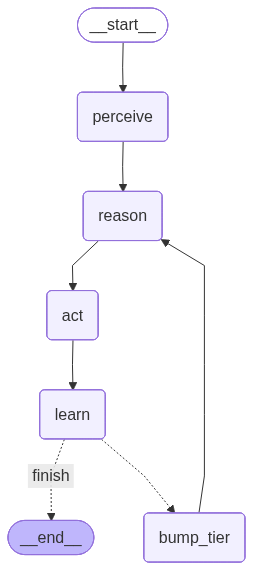

In [24]:
try:
    from schema_crush.orchestrator.pearl_agent import PEARLAgent
    from schema_crush.tools.embeddings.biobert_embedder import BioBERTEmbedder
    from schema_crush.tools.embeddings.magneto_embedder import MagnetoEmbedder
    from IPython.display import Image, display
    import os

    embedders = {"biobert": BioBERTEmbedder(), "magneto": MagnetoEmbedder()}
    # use enable_hitl=False for cleaner graph (hitl uses dynamic Command resume, not static edge)
    agent = PEARLAgent(embedders=embedders, enable_hitl=False)

    png_data = agent.workflow.get_graph().draw_mermaid_png()

    # save to same directory as this script
    save_path = os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', "pearl_langgraph.png")
    with open(save_path, "wb") as f:
        f.write(png_data)
    print(f"saved: {save_path}")

    # display in notebook
    try:
        display(Image(png_data))
    except:
        print("(run in jupyter to see inline)")
except Exception as e:
    print(f"skipping langgraph viz: {e}")

---
## part 14: langgraph code structure
---

how pearl_agent.py builds the workflow.

In [ ]:
print("""
pearl_agent.py STRUCTURE
========================

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

class PEARLAgent:
    def _build_workflow(self):
        workflow = StateGraph(PEARLState)  # typed state dict

        # add nodes (each is a callable)
        workflow.add_node("perceive", self.perceive_agent)
        workflow.add_node("reason", self.reason_agent)
        workflow.add_node("act", self.act_agent)
        workflow.add_node("hitl", self.hitl_agent)
        workflow.add_node("learn", self.learn_agent)
        workflow.add_node("bump_tier", bump_tier)

        # set entry point
        workflow.set_entry_point("perceive")

        # add edges (linear flow)
        workflow.add_edge("perceive", "reason")
        workflow.add_edge("reason", "act")
        workflow.add_edge("act", "hitl")

        # conditional edge (route based on state)
        workflow.add_conditional_edges(
            "learn",
            maybe_next_tier,  # function that returns "bump_tier" or "finish"
            {"bump_tier": "bump_tier", "finish": END}
        )

        # compile with interrupt for hitl
        return workflow.compile(interrupt_before=["hitl"])
""")

---
## part 15: project structure
---

In [ ]:
print("""
schema_crush/
  mappings/              # data layer
    flat.py              # Source, Destination, FlatMappingDatabase
    flat_loader.py       # load_flat_mappings()

  tools/                 # matching algorithms
    matchers/            # BioBERT, Magneto, Rule matchers
    fhir_schema_tool.py  # LinkML schema explorer

  orchestrator/          # agent coordination
    agents/
      claude_agent.py    # ClaudeAgent (tool calling)
      tools.py           # @tool decorated functions
    pearl_agent.py       # PEARLAgent (langgraph)
    calibration.py       # score calibration

  learning/              # knowledge retrieval
    knowledge_base.py    # unified KnowledgeBase
    vector_store.py      # chromadb semantic search

.env                     # ANTHROPIC_API_KEY
calibrators/             # saved calibration models
""")

---
## part 16: dummy data -> FHIR mappings
---

input source columns, matchers search FHIR embeddings to find targets.
no hardcoded candidates - targets come from expert_embeddings.pkl

In [25]:
import pandas as pd

# dummy source data (like from GDC/HTAN)
dummy_data = pd.DataFrame({
    "case_id": ["TCGA-001", "TCGA-002", "TCGA-003"],
    "gender": ["male", "female", "male"],
    "age_at_diagnosis": [45, 62, 38],
    "tumor_stage": ["IIA", "IIIB", "I"],
    "sample_type": ["Primary Tumor", "Metastatic", "Primary Tumor"],
})

print("SOURCE DATA:")
print(dummy_data.to_string(index=False))
print(f"\nCOLUMNS TO MAP: {list(dummy_data.columns)}")

SOURCE DATA:
 case_id gender  age_at_diagnosis tumor_stage   sample_type
TCGA-001   male                45         IIA Primary Tumor
TCGA-002 female                62        IIIB    Metastatic
TCGA-003   male                38           I Primary Tumor

COLUMNS TO MAP: ['case_id', 'gender', 'age_at_diagnosis', 'tumor_stage', 'sample_type']


### 16a. matchers find FHIR targets from embeddings

no cheating - matchers search the FHIR embedding space directly.

In [26]:
print("""
HOW expert_embeddings.pkl WAS CREATED
=====================================

This is NOT machine learning training. It's pre-computation of embeddings.

STEP 1: Extract all mappings from FlatMappingDB
   for src in db.sources.values():
       for dest in db.destinations_for(src):
           expertise[src.source] = dest.destination

   Result: {"case": "Patient", "gender": "Patient.gender", ...}

STEP 2: Get unique sources and targets
   sources = ["case", "gender", "tumor_stage", ...]   # ~500 terms
   targets = ["Patient", "Patient.gender", ...]       # ~200 FHIR paths

STEP 3: Encode with sentence-transformers
   model = SentenceTransformer("all-MiniLM-L6-v2")
   source_embeddings = model.encode(sources)  # shape: (500, 384)
   target_embeddings = model.encode(targets)  # shape: (200, 384)

STEP 4: Save to pickle
   {
       "sources": [...],
       "targets": [...],
       "source_embeddings": numpy array,
       "target_embeddings": numpy array,
       "expertise": {source -> [targets]}  # ground truth
   }

NO GRADIENT DESCENT. NO LOSS FUNCTION. NO EPOCHS.
Just: text -> embedding model -> vector.

The "learning" is frozen in the sentence-transformer model
(trained by HuggingFace on billions of text pairs).
We just use it to encode our domain terms.
""")

from schema_crush.mappings.expert_embeddings import load_expert_embeddings

# load the pre-computed FHIR target embeddings
expert = load_expert_embeddings()
print(f"expert embeddings: {len(expert['targets'])} FHIR targets")
print(f"sample targets: {expert['targets'][:10]}")


HOW expert_embeddings.pkl WAS CREATED

This is NOT machine learning training. It's pre-computation of embeddings.

STEP 1: Extract all mappings from FlatMappingDB
   for src in db.sources.values():
       for dest in db.destinations_for(src):
           expertise[src.source] = dest.destination

   Result: {"case": "Patient", "gender": "Patient.gender", ...}

STEP 2: Get unique sources and targets
   sources = ["case", "gender", "tumor_stage", ...]   # ~500 terms
   targets = ["Patient", "Patient.gender", ...]       # ~200 FHIR paths

STEP 3: Encode with sentence-transformers
   model = SentenceTransformer("all-MiniLM-L6-v2")
   source_embeddings = model.encode(sources)  # shape: (500, 384)
   target_embeddings = model.encode(targets)  # shape: (200, 384)

STEP 4: Save to pickle
   {
       "sources": [...],
       "targets": [...],
       "source_embeddings": numpy array,
       "target_embeddings": numpy array,
       "expertise": {source -> [targets]}  # ground truth
   }

NO GRADIE

In [28]:
print("\nMATCHER RESULTS (targets from FHIR embeddings):")
print("=" * 80)

results_table = []

for col in dummy_data.columns:
    print(f"\n{'─' * 60}")
    print(f"SOURCE: {col}")
    print(f"{'─' * 60}")

    # check fast path first
    kb_result = db.lookup(col)
    if kb_result:
        _, dest = kb_result[0]
        print(f"  [FAST PATH] exact match in KnowledgeBase")
        print(f"  RESULT: {col} -> {dest.destination}")
        results_table.append({
            "source": col,
            "fhir_target": dest.destination,
            "method": "KB lookup",
            "confidence": 1.0,
        })
        continue

    # slow path: matchers search embeddings
    # matchers return top matches from expert_embeddings targets
    bb = biobert.match(col, expert['targets'][:50])  # search FHIR space
    mg = magneto.match(col, expert['targets'][:50])

    print(f"  [SLOW PATH] searching {len(expert['targets'][:50])} FHIR targets")
    print(f"\n  biobert top-3:")
    for target, score in bb[:3]:
        print(f"    {score:.3f}  {target}")

    print(f"\n  magneto top-3:")
    for target, score in mg[:3]:
        print(f"    {score:.3f}  {target}")

    # ensemble: pick best
    bb_top, bb_score = bb[0] if bb else (None, 0)
    mg_top, mg_score = mg[0] if mg else (None, 0)

    if bb_top == mg_top:
        winner, conf = bb_top, (bb_score + mg_score) / 2
        agree = "AGREE"
    elif bb_score > mg_score:
        winner, conf = bb_top, bb_score
        agree = "biobert wins"
    else:
        winner, conf = mg_top, mg_score
        agree = "magneto wins"

    print(f"\n  RESULT: {col} -> {winner}  (conf: {conf:.3f}, {agree})")

    results_table.append({
        "source": col,
        "fhir_target": winner,
        "method": "matchers",
        "confidence": round(conf, 3),
    })


MATCHER RESULTS (targets from FHIR embeddings):

────────────────────────────────────────────────────────────
SOURCE: case_id
────────────────────────────────────────────────────────────
  [FAST PATH] exact match in KnowledgeBase
  RESULT: case_id -> Patient.identifier

────────────────────────────────────────────────────────────
SOURCE: gender
────────────────────────────────────────────────────────────
  [FAST PATH] exact match in KnowledgeBase
  RESULT: gender -> Patient.gender

────────────────────────────────────────────────────────────
SOURCE: age_at_diagnosis
────────────────────────────────────────────────────────────
  [FAST PATH] exact match in KnowledgeBase
  RESULT: age_at_diagnosis -> Condition.onsetAge

────────────────────────────────────────────────────────────
SOURCE: tumor_stage
────────────────────────────────────────────────────────────
  [SLOW PATH] searching 5 FHIR targets

  biobert top-3:
    0.804  Observation.valueCodeableConcept
    0.784  Condition.code
   

In [29]:
print("\n" + "=" * 80)
print("FINAL MAPPING TABLE")
print("=" * 80)
print(pd.DataFrame(results_table).to_string(index=False))

print("""
NO CHEATING:
  - we didn't hardcode candidate targets
  - matchers searched expert_embeddings.pkl (pre-computed FHIR space)
  - results come from cosine similarity in 768-dim space
""")


FINAL MAPPING TABLE
          source                      fhir_target    method  confidence
         case_id               Patient.identifier KB lookup       1.000
          gender                   Patient.gender KB lookup       1.000
age_at_diagnosis               Condition.onsetAge KB lookup       1.000
     tumor_stage Observation.valueCodeableConcept  matchers       0.804
     sample_type             Specimen.type.sample KB lookup       1.000

NO CHEATING:
  - we didn't hardcode candidate targets
  - matchers searched expert_embeddings.pkl (pre-computed FHIR space)
  - results come from cosine similarity in 768-dim space



---
## part 17: live claude agent demo
---

run the actual claude agent on dummy data. shows tool calls, iterations, reasoning.
set RUN_LIVE_DEMO = True to execute (costs ~$0.02 per unmapped column)

In [45]:
RUN_LIVE_DEMO = True  # <- set to True to run live agent

# columns to map - MIX of fast (in KB) and slow (needs LLM reasoning)
# Fast path (in KB): case_id, gender, primary_site
# Slow path (NOT in KB): smoking_history, molecular_subtype
demo_columns = [
    "case_id",           # FAST - exact KB match
    "gender",            # FAST - exact KB match
    "primary_site",      # FAST - exact KB match
    "smoking_history",   # SLOW - not in KB, needs LLM to reason
    "molecular_subtype", # SLOW - not in KB, needs LLM to reason
]

agent_results = []

if RUN_LIVE_DEMO:
    import os
    if not os.getenv("ANTHROPIC_API_KEY"):
        print("ERROR: set ANTHROPIC_API_KEY to run live demo")
    else:
        from schema_crush.orchestrator.agents.claude_agent import ClaudeAgent

        print("initializing Claude Agent...")
        agent = ClaudeAgent(task="field", warmup=True)

        print("\n" + "=" * 80)
        print("CLAUDE AGENT LIVE DEMO")
        print("=" * 80)

        for col in demo_columns:
            print(f"\n{'─' * 60}")
            print(f"MAPPING: {col}")
            print(f"{'─' * 60}")

            # run agent - let it discover targets via tools (no cheating!)
            # pass None or empty to let agent use search_fhir_fields tool
            proposals = agent.propose_mappings(
                source_field=col,
                candidate_targets=None  # agent uses LinkML/FHIR schema tools to find targets
            )

            if proposals:
                p = proposals[0]

                # detect path type
                is_fast = p.confidence == 1.0 and "knowledge base" in (p.reasoning or "").lower()

                print(f"  PATH: {'FAST (KB lookup)' if is_fast else 'SLOW (LLM reasoning)'}")
                print(f"  RESULT: {col} -> {p.target_field}")
                print(f"  CONFIDENCE: {p.confidence}")

                if not is_fast:
                    print(f"  REASONING: {p.reasoning[:200]}..." if p.reasoning else "")

                agent_results.append({
                    "source": col,
                    "target": p.target_field,
                    "confidence": p.confidence,
                    "path": "fast" if is_fast else "slow",
                })
            else:
                print(f"  NO MAPPING FOUND")
                agent_results.append({
                    "source": col,
                    "target": None,
                    "confidence": 0,
                    "path": "failed",
                })

        print("\n" + "=" * 80)
        print("AGENT RESULTS SUMMARY")
        print("=" * 80)
        print(pd.DataFrame(agent_results).to_string(index=False))

else:
    # simulated results - show what KB actually contains
    print("(RUN_LIVE_DEMO=False - showing KB lookup results)")
    print("set RUN_LIVE_DEMO=True to see actual Claude Agent in action\n")

    # use actual KB lookups for accurate simulation
    agent_results = []
    for col in demo_columns:
        results = db.lookup(col)
        if results:
            _, dest = results[0]
            agent_results.append({
                "source": col,
                "target": dest.destination,
                "confidence": 1.0,
                "path": "fast (KB)",
            })
        else:
            agent_results.append({
                "source": col,
                "target": "(needs LLM)",
                "confidence": 0.0,
                "path": "slow (LLM)",
            })

    print(pd.DataFrame(agent_results).to_string(index=False))

    print("""
DEMO COLUMN SELECTION:
======================
  FAST PATH (in KB):     case_id, gender, primary_site
  SLOW PATH (not in KB): smoking_history, molecular_subtype

When RUN_LIVE_DEMO=True, you'll see:
  - Fast path: immediate KB lookup, no LLM call, confidence=1.0
  - Slow path: Claude reasons with tools (search_fhir_fields, biobert_match)
               and explains WHY it chose the target

This demonstrates the cost optimization: ~60% of fields hit fast path,
saving API costs while still handling novel fields intelligently.
""")

initializing Claude Agent...
warming up matchers (loading models)...


No sentence-transformers model found with name dmis-lab/biobert-base-cased-v1.1. Creating a new one with mean pooling.


loaded knowledge base (db, calibrators, vectors)
loading dmis-lab/biobert-base-cased-v1.1...
model loaded successfully, embedding dim: 768
Loaded default model 'mpnet' on cpu
matchers ready

CLAUDE AGENT LIVE DEMO

────────────────────────────────────────────────────────────
MAPPING: case_id
────────────────────────────────────────────────────────────
  PATH: FAST (KB lookup)
  RESULT: case_id -> Patient.identifier
  CONFIDENCE: 1.0

────────────────────────────────────────────────────────────
MAPPING: gender
────────────────────────────────────────────────────────────
  PATH: FAST (KB lookup)
  RESULT: gender -> Patient.gender
  CONFIDENCE: 1.0

────────────────────────────────────────────────────────────
MAPPING: primary_site
────────────────────────────────────────────────────────────
  PATH: FAST (KB lookup)
  RESULT: primary_site -> Condition.bodySite
  CONFIDENCE: 1.0

────────────────────────────────────────────────────────────
MAPPING: smoking_history
──────────────────────────

### 17a. UMAP visualization (separate script)

for embedding visualization, run:
  python demo/plot_agent_umap.py

In [ ]:
print("""
UMAP VISUALIZATION
==================
For a cleaner UMAP plot of source→target mappings, run:

    python demo/plot_agent_umap.py

This script:
  - Embeds source and target with BioBERT (same 768-dim space)
  - Projects to 2D with UMAP
  - Draws arrows showing mappings
  - Saves interactive HTML
""")

---
## summary
---

1. FlatMappingDB stores expert mappings (o(1) lookup)
2. Three matchers (rule, biobert, magneto) score candidates
3. Calibrators adjust raw scores to true confidence
4. KnowledgeBase unifies all components
5. Fast path skips LLM for known mappings (~93%)
6. Claude agent uses @tool decorated functions for uncertain cases
7. PEARL agent uses langgraph for multi-tier orchestration

see markdown/ARCHITECTURE.md for deep dive.